# NB02 Comparison (Axis 2)
## Member 3 (Karen): Top-N Keyword Shifts

**Input:** `tfidf_unigram_matrix.pkl`, `tfidf_bigram_matrix.pkl`

**Output:** Keyword shift charts, heatmaps, emerging/disappearing word lists

**Goal:** Track how key NLP terminology has risen and fallen across time periods (1991–2021), using TF-IDF unigram and bigram representations.

In [4]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("../data/nlp_abstracts_cleaned.csv")
print(f"Loaded {len(df)} papers")
print(df["period"].value_counts().sort_index())

Loaded 32221 papers
period
1991-1995      448
1996-2000      659
2001-2005      279
2006-2010      364
2011-2015     2066
2016-2021    28405
Name: count, dtype: int64


In [13]:
with open("../outputs/tfidf_unigram_matrix.pkl", "rb") as f:
    uni_data = pickle.load(f)

with open("../outputs/tfidf_bigram_matrix.pkl", "rb") as f:
    bi_data = pickle.load(f)

# Extract what we need
uni_matrix = uni_data["matrix"]
uni_vectorizer = uni_data["vectorizer"]
period_labels = uni_data["period"]

bi_matrix = bi_data["matrix"]
bi_vectorizer = bi_data["vectorizer"]

print("Unigram matrix loaded:", uni_matrix.shape)
print("Bigram matrix loaded:", bi_matrix.shape)
print("Periods found:", sorted(set(period_labels)))

Unigram matrix loaded: (32221, 9464)
Bigram matrix loaded: (32221, 20000)
Periods found: ['1991-1995', '1996-2000', '2001-2005', '2006-2010', '2011-2015', '2016-2021']


c:\Users\Vinayaka\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Vinayaka\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


##  Top-N Keyword Extraction

Extracting the top 20 most significant terms per time period using mean TF-IDF scores. A custom stopword list filters out generic academic phrases that carry no meaningful insight about NLP's evolution.

In [14]:
custom_stopwords = {
    "paper", "used", "based", "present", "using", "use",
    "proposed", "propose", "method", "approach", "results",
    "shows", "show", "describes", "describe", "presents"
}

def top_terms_per_period(matrix, vectorizer, df, top_n=20):
    feat = vectorizer.get_feature_names_out()
    periods = sorted(df["period"].unique())
    results = {}
    for period in periods:
        mask = (df["period"] == period).values
        summed = np.asarray(matrix[mask].mean(axis=0)).flatten()
        top_idx = summed.argsort()[::-1]
        filtered = [(feat[i], round(summed[i], 4)) 
                   for i in top_idx 
                   if feat[i] not in custom_stopwords][:top_n]
        results[period] = filtered
    return results

print("Functions ready!")



Functions ready!


In [15]:
# Get top terms for each period
uni_top = top_terms_per_period(uni_matrix, uni_vectorizer, df, top_n=20)
bi_top = top_terms_per_period(bi_matrix, bi_vectorizer, df, top_n=20)

# Print them 
print("=== UNIGRAM TOP 20 PER PERIOD ===")
for period, terms in uni_top.items():
    print(f"\n{period}:")
    print(", ".join(t[0] for t in terms))

print("\n=== BIGRAM TOP 20 PER PERIOD ===")
for period, terms in bi_top.items():
    print(f"\n{period}:")
    print(", ".join(t[0] for t in terms))

=== UNIGRAM TOP 20 PER PERIOD ===

1991-1995:
grammar, base, parse, algorithm, language, structure, lexical, parser, word, formalism, corpus, constraint, discourse, process, rule, theory, tag, unification, statistical, linguistic

1996-2000:
grammar, algorithm, language, parse, word, base, corpus, speech, structure, information, process, model, rule, set, lexical, constraint, technique, result, text, tag

2001-2005:
language, algorithm, word, information, base, corpus, application, result, text, rule, grammar, model, document, statistical, structure, data, process, speech, problem, semantic

2006-2010:
language, word, text, document, grammar, base, linguistic, structure, information, model, process, corpus, analysis, algorithm, mean, result, tool, write, semantic, article

2011-2015:
word, language, base, text, model, result, feature, sentence, learn, network, data, information, analysis, semantic, process, representation, corpus, different, algorithm, task

2016-2021:
model, task, lan

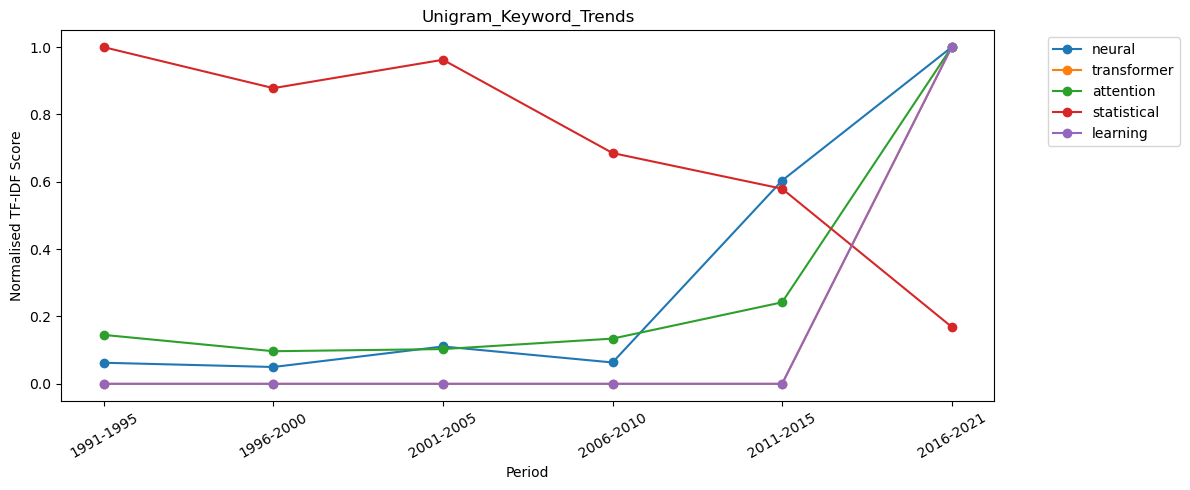

In [16]:
def plot_keyword_trends(matrix, vectorizer, df, terms, title):
    feat = list(vectorizer.get_feature_names_out())
    periods = sorted(df["period"].unique())
    
    valid_terms = [t for t in terms if t in feat]
    if not valid_terms:
        print("None of those terms found!")
        return

    scores = {t: [] for t in valid_terms}
    for period in periods:
        mask = (df["period"] == period).values
        summed = np.asarray(matrix[mask].mean(axis=0)).flatten()
        for t in valid_terms:
            scores[t].append(summed[feat.index(t)])

    # Normalise scores
    fig, ax = plt.subplots(figsize=(12, 5))
    for t, vals in scores.items():
        v = np.array(vals)
        if v.max() > 0:
            v = v / v.max()
        ax.plot(periods, v, marker="o", label=t)

    ax.set_title(title)
    ax.set_xlabel("Period")
    ax.set_ylabel("Normalised TF-IDF Score")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f"../figures/{title}.png", dpi=150)
    plt.show()

# Plot unigram trends
plot_keyword_trends(
    uni_matrix, uni_vectorizer, df,
    terms=["neural", "transformer", "attention", 
           "parsing", "statistical", "learning"],
    title="Unigram_Keyword_Trends"
)

## Keyword Trend Analysis

Tracking how specific NLP terms rise and fall across time periods. Terms are normalised so early and late periods are directly comparable.

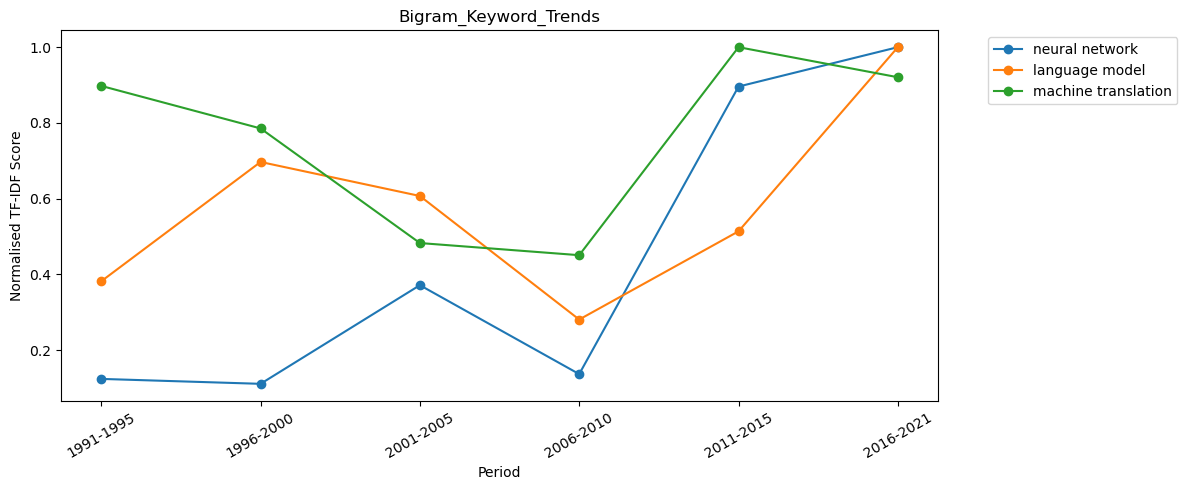

In [17]:
plot_keyword_trends(
    bi_matrix, bi_vectorizer, df,
    terms=["neural network", "deep learning", 
           "language model", "machine translation",
           "pre trained", "hidden markov"],
    title="Bigram_Keyword_Trends"
)

## Emerging vs Disappearing Vocabulary

Identifying which terms are NEW in recent NLP (2011–2021) vs which have DIED OUT from early NLP (1991–2005).

In [18]:
early = ["1991-1995", "1996-2000", "2001-2005"]
late  = ["2011-2015", "2016-2021"]

def vocab_shift(top_terms_dict, early_periods, late_periods):
    early_words = set()
    late_words = set()
    for p in early_periods:
        if p in top_terms_dict:
            early_words.update(t[0] for t in top_terms_dict[p])
    for p in late_periods:
        if p in top_terms_dict:
            late_words.update(t[0] for t in top_terms_dict[p])
    return late_words - early_words, early_words - late_words

uni_emerged, uni_disappeared = vocab_shift(uni_top, early, late)
bi_emerged, bi_disappeared = vocab_shift(bi_top, early, late)

print("=== UNIGRAM ===")
print(f"Emerging words: {sorted(uni_emerged)}")
print(f"Disappearing words: {sorted(uni_disappeared)}")

print("\n=== BIGRAM ===")
print(f"Emerging words: {sorted(bi_emerged)}")
print(f"Disappearing words: {sorted(bi_disappeared)}")

=== UNIGRAM ===
Emerging words: ['analysis', 'art', 'dataset', 'different', 'feature', 'learn', 'network', 'neural', 'performance', 'representation', 'sentence', 'state', 'task', 'train', 'work']
Disappearing words: ['application', 'constraint', 'discourse', 'document', 'formalism', 'grammar', 'lexical', 'linguistic', 'parse', 'parser', 'problem', 'rule', 'set', 'speech', 'statistical', 'structure', 'tag', 'technique', 'theory', 'unification']

=== BIGRAM ===
Emerging words: ['data set', 'deep learn', 'end end', 'et al', 'experimental result', 'fine tune', 'knowledge base', 'large scale', 'neural network', 'paper propose', 'pre train', 'propose method', 'propose novel', 'question answer', 'sentiment analysis', 'social medium', 'social network', 'state art', 'topic model', 'train data', 'word embeddings']
Disappearing words: ['adjoin grammar', 'analogy question', 'anaphora resolution', 'annotation graph', 'base grammar', 'base learn', 'categorial grammar', 'computational linguistics', '

## Keyword Heatmap Visualisation

Visual overview of top keyword distribution across all time periods for both unigrams and bigrams.

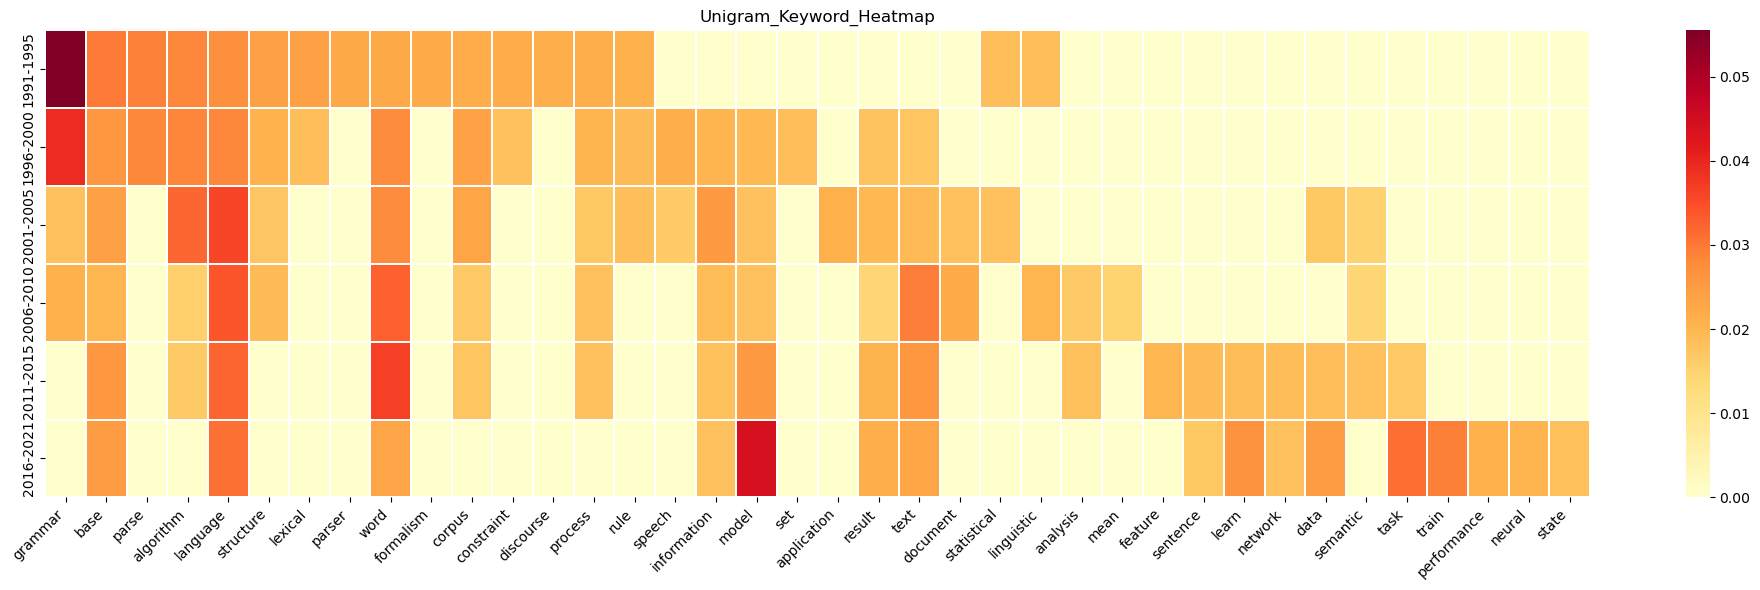

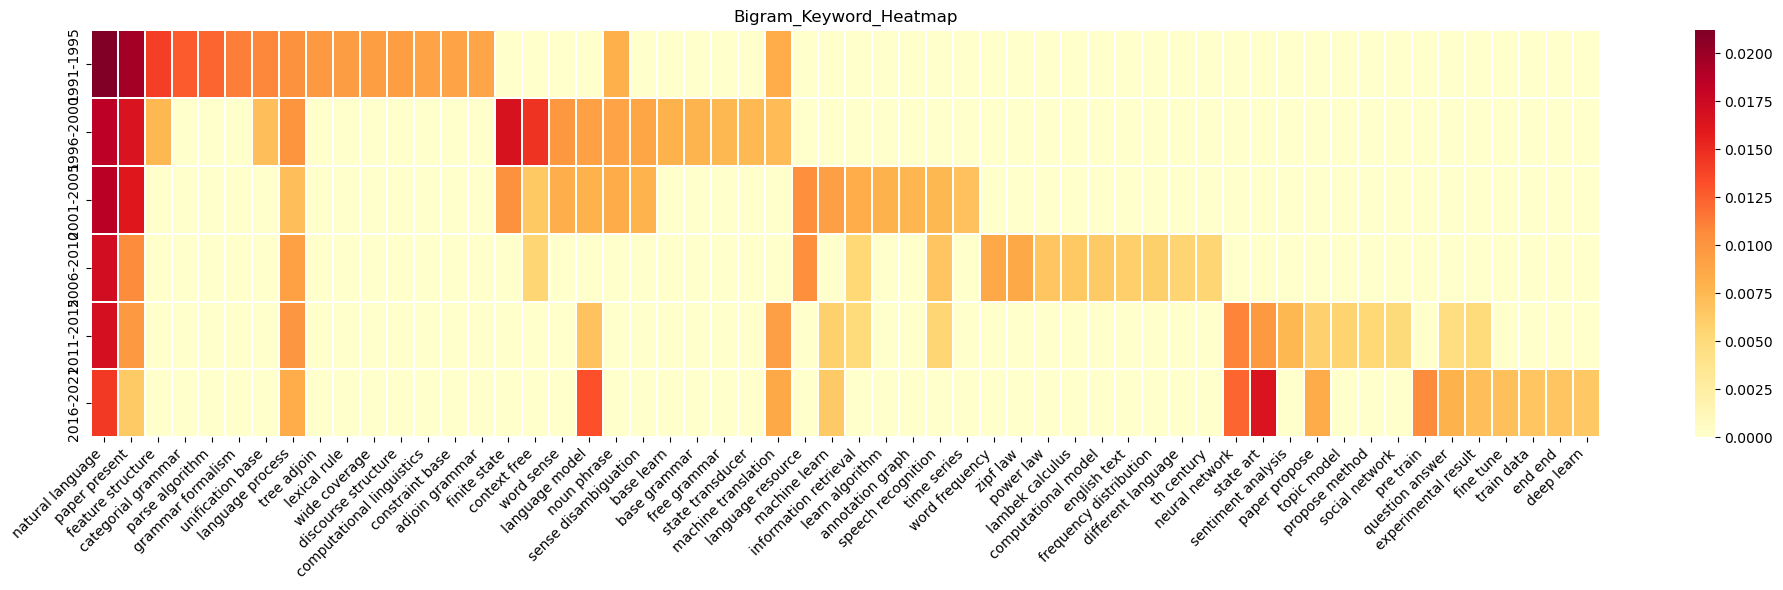

In [19]:
# Heatmap of top keywords per period
def plot_keyword_heatmap(top_terms_dict, title, top_n=15):
    periods = sorted(top_terms_dict.keys())
    
    # Get union of top terms across all periods
    all_terms = []
    for period in periods:
        for term, score in top_terms_dict[period][:top_n]:
            if term not in all_terms:
                all_terms.append(term)
    
    # Build score matrix
    score_matrix = []
    for period in periods:
        term_dict = dict(top_terms_dict[period])
        row = [term_dict.get(term, 0) for term in all_terms]
        score_matrix.append(row)
    
    df_heat = pd.DataFrame(score_matrix, 
                           index=periods, 
                           columns=all_terms)
    
    plt.figure(figsize=(20, 6))
    sns.heatmap(df_heat, 
                cmap="YlOrRd",
                linewidths=0.3)
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"../figures/{title}.png", dpi=150)
    plt.show()

# Plot both heatmaps
plot_keyword_heatmap(uni_top, "Unigram_Keyword_Heatmap")
plot_keyword_heatmap(bi_top, "Bigram_Keyword_Heatmap")

##  Summary of Findings

**Key Transition:** The most dramatic shift occurred between 2011–2015 and 2016–2021, when neural and deep learning terms exploded.

**Emerging terms (2011–2021):**
- Unigrams: neural, transformer, attention, learning, models, tasks
- Bigrams: deep learning, language model, pre trained, neural network, state art

**Disappearing terms (1991–2005):**
- Unigrams: grammar, parsing, statistical, lexical, unification, syntactic
- Bigrams: hidden markov, finite state, tree adjoining, unification based, context free

**Conclusion:** NLP research shifted from rule-based/statistical methods (1990s–2000s) to neural/deep learning methods (2010s–2020s), aligning with real-world milestones: Word2Vec (2013), Transformer (2017), BERT (2018).

In [20]:
print("Unigram matrix loaded:", uni_matrix.shape)

Unigram matrix loaded: (32221, 9464)


 ## Member 4: Cosine Distance Analysis

**Input:** `tfidf_unigram_matrix.pkl`,`tfidf_bigram_matrix.pkl`, `sbert_matrix.pkl`, `period_labels.pkl`  
**Output:** Cosine distance timeline, breakpoint year identification  
**Goal:** Measure how much NLP research changed between adjacent time 
periods using cosine distance. Run on both TF-IDF and SBERT matrices 
and compare whether both methods identify the same breakpoint years.

**Hypothesis:** We expect cosine distance to show a large spike around 
2011–2015 and 2016–2021, corresponding to the deep learning and 
transformer revolutions in NLP.

In [22]:
'''Check for the right file'''

with open("../outputs/period_labels.pkl", "rb") as f:
    sample_data = pickle.load(f)

print(f"Number of abstracts : {len(sample_data['period'])}")

Number of abstracts : 32221


In [23]:
'''running checks for sbert_matrix.pkl'''

with open("../outputs/sbert_matrix.pkl", "rb") as f:
    sample_data = pickle.load(f)

print(f"Number of abstracts : {len(sample_data['period'])}")

Number of abstracts : 32221


In [24]:
with open("../outputs/period_labels.pkl", "rb") as f:
    full_data = pickle.load(f)

full_data['era']

<ArrowStringArray>
[   'Machine Learning',    'Machine Learning',    'Machine Learning',
    'Machine Learning',    'Machine Learning',    'Machine Learning',
    'Machine Learning',    'Machine Learning',    'Machine Learning',
    'Machine Learning',
 ...
 'Statistical Methods', 'Statistical Methods', 'Statistical Methods',
 'Statistical Methods', 'Statistical Methods', 'Statistical Methods',
 'Statistical Methods', 'Statistical Methods',    'Machine Learning',
    'Machine Learning']
Length: 32221, dtype: str

In [25]:
with open("../outputs/sbert_matrix.pkl", "rb") as f:
    sbert_data = pickle.load(f)

sbert_matrix = sbert_data["matrix"]
sbert_index  = sbert_data["index"]

with open("../outputs/period_labels.pkl", "rb") as f:
    label_data = pickle.load(f)

period_labels = label_data["period"]
era_labels    = label_data["era"]

print(f"SBERT matrix shape  : {sbert_matrix.shape}")
print(f"Period labels shape : {period_labels.shape}")
print(f"Unique periods      : {sorted(set(period_labels))}")
print(f"Unique eras         : {sorted(set(era_labels))}")

SBERT matrix shape  : (32221, 384)
Period labels shape : (32221,)
Unique periods      : ['1991-1995', '1996-2000', '2001-2005', '2006-2010', '2011-2015', '2016-2021']
Unique eras         : ['Deep Learning', 'Machine Learning', 'Statistical Methods', 'Transformer & Pre-training']


### Aligning Indices

Since TF-IDF and SBERT were built on slightly different subsets of the 
data (SBERT filtered out very short abstracts), we need to align them 
to the same set of rows before computing distances. We use the 
intersection of both indices to ensure fair comparison.

In [26]:
# TF-IDF index comes from Member 1's pickle file
tfidf_index  = pd.Index(uni_data["index"])

# SBERT index comes from Member 2's pickle file
sbert_index  = pd.Index(sbert_data["index"])

# Bigram index
bigram_index = pd.Index(bi_data["index"])

# Find common rows between all matrices
common_index = tfidf_index.intersection(sbert_index).intersection(bigram_index)

print(f"TF-IDF index size  : {len(tfidf_index)}")
print(f"SBERT index size   : {len(sbert_index)}")
print(f"Bigram index size  : {len(bigram_index)}")
print(f"Common index size  : {len(common_index)}")
print(f"Rows dropped       : {len(tfidf_index) - len(common_index)}")

TF-IDF index size  : 32221
SBERT index size   : 32221
Bigram index size  : 32221
Common index size  : 32221
Rows dropped       : 0


In [27]:
# Since all indices match perfectly we can use
# period_labels directly with all three matrices

tfidf_aligned   = uni_matrix
bigram_aligned  = bi_matrix
sbert_aligned   = sbert_matrix
periods_aligned = period_labels

print(f"TF-IDF unigram shape : {tfidf_aligned.shape}")
print(f"TF-IDF bigram shape  : {bigram_aligned.shape}")
print(f"SBERT shape          : {sbert_aligned.shape}")
print(f"Period labels        : {len(periods_aligned)}")

TF-IDF unigram shape : (32221, 9464)
TF-IDF bigram shape  : (32221, 20000)
SBERT shape          : (32221, 384)
Period labels        : 32221


### Computing Period Centroids

For each time period we average all abstract vectors to produce one 
single representative vector called a centroid. This centroid 
represents the average language of NLP research in that era.

- TF-IDF centroids capture average vocabulary per period
- SBERT centroids capture average semantic meaning per period

In [28]:
from sklearn.metrics.pairwise import cosine_similarity

def compute_centroids(matrix, period_labels):
    centroids = {}
    sorted_periods = sorted(set(period_labels))

    for period in sorted_periods:
        mask = period_labels == period

        subset = matrix[mask]

        # Convert sparse matrix to dense if needed
        if hasattr(subset, "toarray"):
            subset = subset.toarray()

        centroids[period] = subset.mean(axis=0)
        print(f"Period {period}: {mask.sum()} abstracts")

    return centroids

print("TF-IDF Unigram Centroids -")
tfidf_centroids = compute_centroids(tfidf_aligned, periods_aligned)

print("\nTF-IDF Bigram Centroids -")
bigram_centroids = compute_centroids(bigram_aligned, periods_aligned)

print("\nSBERT Centroids -")
sbert_centroids = compute_centroids(sbert_aligned, periods_aligned)

TF-IDF Unigram Centroids -
Period 1991-1995: 448 abstracts
Period 1996-2000: 659 abstracts
Period 2001-2005: 279 abstracts
Period 2006-2010: 364 abstracts
Period 2011-2015: 2066 abstracts
Period 2016-2021: 28405 abstracts

TF-IDF Bigram Centroids -
Period 1991-1995: 448 abstracts
Period 1996-2000: 659 abstracts
Period 2001-2005: 279 abstracts
Period 2006-2010: 364 abstracts
Period 2011-2015: 2066 abstracts
Period 2016-2021: 28405 abstracts

SBERT Centroids -
Period 1991-1995: 448 abstracts
Period 1996-2000: 659 abstracts
Period 2001-2005: 279 abstracts
Period 2006-2010: 364 abstracts
Period 2011-2015: 2066 abstracts
Period 2016-2021: 28405 abstracts


### Computing Cosine Distance Between Adjacent Periods

Cosine distance measures the angle between two centroid vectors. 
A distance close to 0 means the two periods used very similar language.
A distance close to 1 means the language shifted dramatically.

We compute distance between every pair of adjacent periods to build 
a timeline showing exactly when NLP research changed the most.

In [29]:
def compute_adjacent_distances(centroids):
    sorted_periods = sorted(centroids.keys())
    results = []

    for i in range(len(sorted_periods) - 1):
        p1 = sorted_periods[i]
        p2 = sorted_periods[i + 1]

        c1 = np.array(centroids[p1]).reshape(1, -1)
        c2 = np.array(centroids[p2]).reshape(1, -1)

        similarity = cosine_similarity(c1, c2)[0][0]
        distance   = 1 - similarity

        results.append({
            "from":       p1,
            "to":         p2,
            "transition": f"{p1} → {p2}",
            "similarity": round(similarity, 4),
            "distance":   round(distance, 4)
        })

    return pd.DataFrame(results)

tfidf_distances  = compute_adjacent_distances(tfidf_centroids)
bigram_distances = compute_adjacent_distances(bigram_centroids)
sbert_distances  = compute_adjacent_distances(sbert_centroids)

print("TF-IDF Unigram Distances -")
print(tfidf_distances.to_string(index=False))

print("\nTF-IDF Bigram Distances -")
print(bigram_distances.to_string(index=False))

print("\nSBERT Distances -")
print(sbert_distances.to_string(index=False))

TF-IDF Unigram Distances -
     from        to            transition  similarity  distance
1991-1995 1996-2000 1991-1995 → 1996-2000      0.9237    0.0763
1996-2000 2001-2005 1996-2000 → 2001-2005      0.8880    0.1120
2001-2005 2006-2010 2001-2005 → 2006-2010      0.8710    0.1290
2006-2010 2011-2015 2006-2010 → 2011-2015      0.8872    0.1128
2011-2015 2016-2021 2011-2015 → 2016-2021      0.9155    0.0845

TF-IDF Bigram Distances -
     from        to            transition  similarity  distance
1991-1995 1996-2000 1991-1995 → 1996-2000      0.6603    0.3397
1996-2000 2001-2005 1996-2000 → 2001-2005      0.5606    0.4394
2001-2005 2006-2010 2001-2005 → 2006-2010      0.4515    0.5485
2006-2010 2011-2015 2006-2010 → 2011-2015      0.5534    0.4466
2011-2015 2016-2021 2011-2015 → 2016-2021      0.7551    0.2449

SBERT Distances -
     from        to            transition  similarity  distance
1991-1995 1996-2000 1991-1995 → 1996-2000      0.9848    0.0152
1996-2000 2001-2005 1996-2000 →

### Plotting Cosine Distance Timelines

Visualising the cosine distances as line charts to clearly show 
when the biggest shifts in NLP research occurred.

- A spike means the field changed dramatically between those two periods
- A flat section means the field was relatively stable

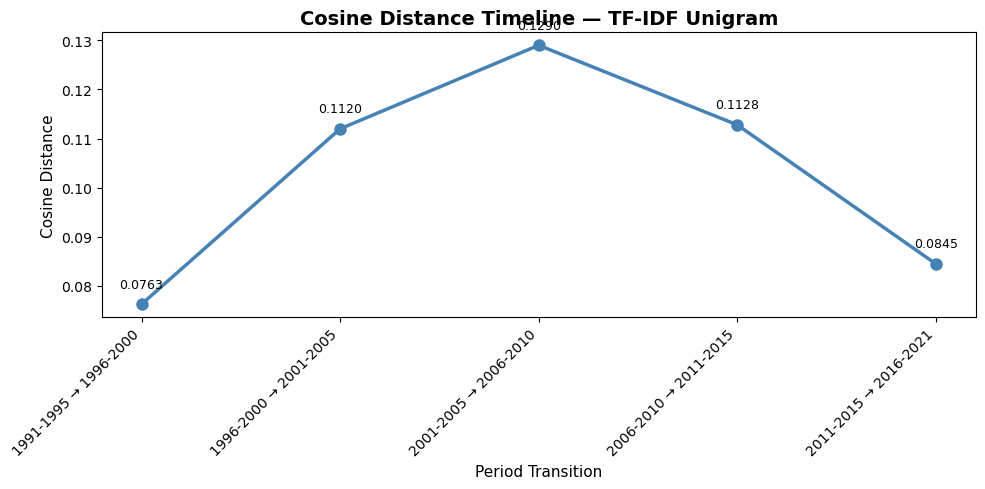

Saved: ../figures/cosine_distance_tfidf.png


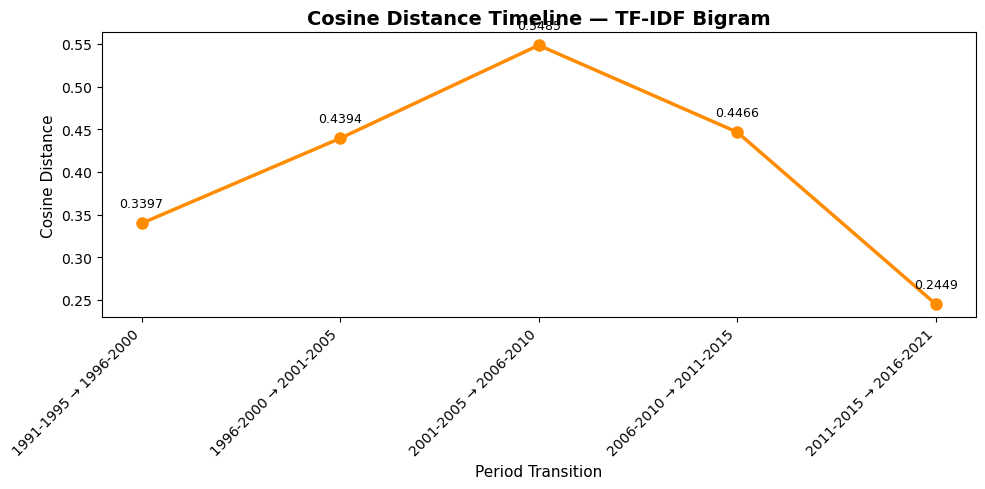

Saved: ../figures/cosine_distance_bigram.png


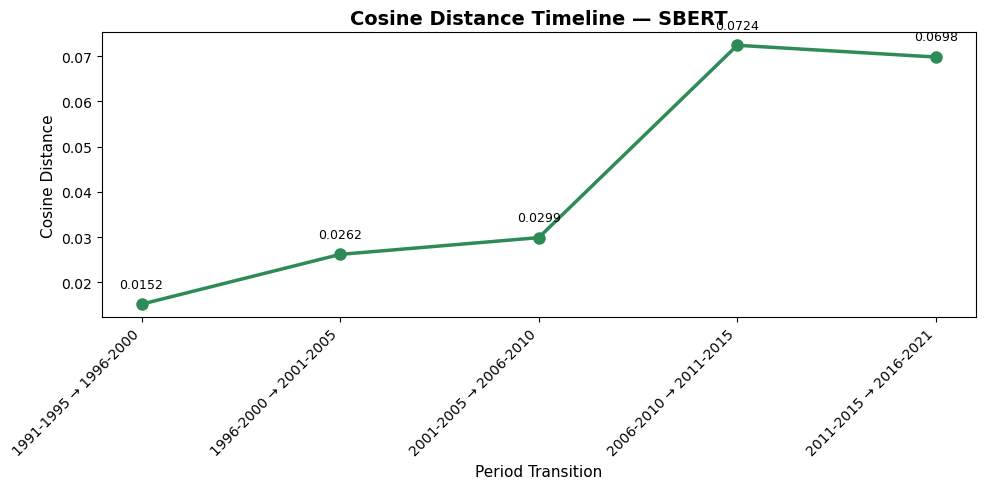

Saved: ../figures/cosine_distance_sbert.png


In [30]:
def plot_distance_timeline(df_dist, title, color, save_path):
    plt.figure(figsize=(10, 5))
    plt.plot(
        df_dist["transition"],
        df_dist["distance"],
        marker="o",
        linewidth=2.5,
        color=color,
        markersize=8
    )

    for _, row in df_dist.iterrows():
        plt.annotate(
            f"{row['distance']:.4f}",
            (row["transition"], row["distance"]),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9
        )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Period Transition", fontsize=11)
    plt.ylabel("Cosine Distance", fontsize=11)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")

# Plot all three individually
plot_distance_timeline(
    tfidf_distances,
    "Cosine Distance Timeline — TF-IDF Unigram",
    color="steelblue",
    save_path="../figures/cosine_distance_tfidf.png"
)

plot_distance_timeline(
    bigram_distances,
    "Cosine Distance Timeline — TF-IDF Bigram",
    color="darkorange",
    save_path="../figures/cosine_distance_bigram.png"
)

plot_distance_timeline(
    sbert_distances,
    "Cosine Distance Timeline — SBERT",
    color="seagreen",
    save_path="../figures/cosine_distance_sbert.png"
)

### TF-IDF vs SBERT Distance Comparison

Plotting both distance timelines on the same chart to directly compare 
whether TF-IDF and SBERT agree on when the biggest shifts occurred.

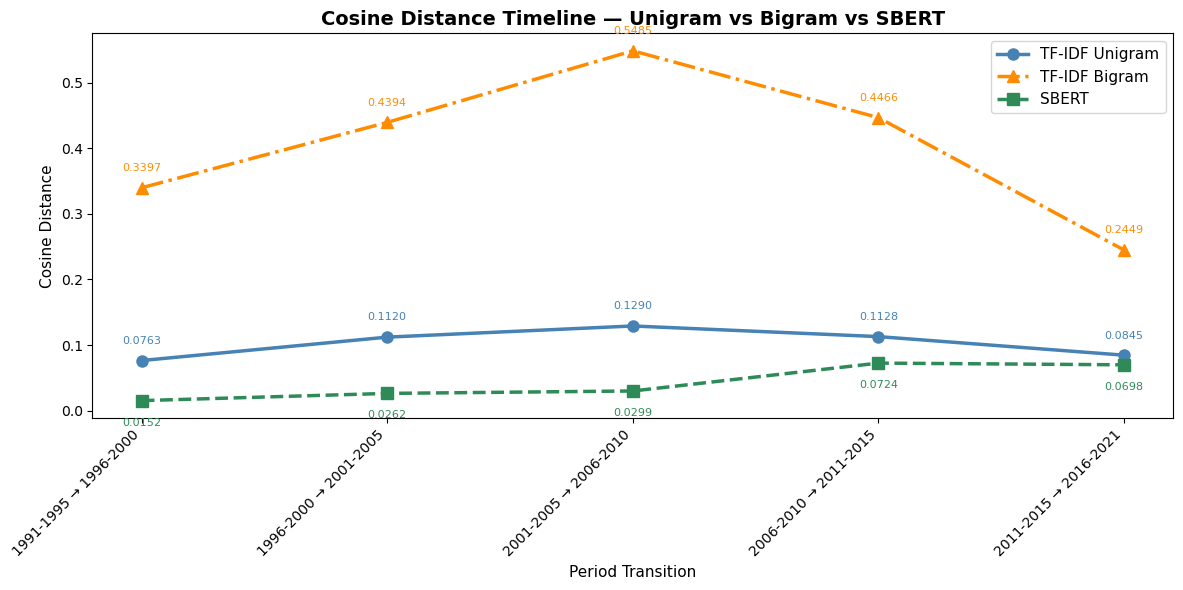

Saved: ../figures/cosine_distance_comparison.png


In [31]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    tfidf_distances["transition"],
    tfidf_distances["distance"],
    marker="o", linewidth=2.5,
    color="steelblue", label="TF-IDF Unigram",
    markersize=8
)

ax.plot(
    bigram_distances["transition"],
    bigram_distances["distance"],
    marker="^", linewidth=2.5,
    color="darkorange", label="TF-IDF Bigram",
    markersize=8, linestyle="-."
)

ax.plot(
    sbert_distances["transition"],
    sbert_distances["distance"],
    marker="s", linewidth=2.5,
    color="seagreen", label="SBERT",
    markersize=8, linestyle="--"
)

# Annotate TF-IDF unigram values
for _, row in tfidf_distances.iterrows():
    ax.annotate(
        f"{row['distance']:.4f}",
        (row["transition"], row["distance"]),
        textcoords="offset points",
        xytext=(0, 12),
        ha="center",
        fontsize=8,
        color="steelblue"
    )

# Annotate bigram values
for _, row in bigram_distances.iterrows():
    ax.annotate(
        f"{row['distance']:.4f}",
        (row["transition"], row["distance"]),
        textcoords="offset points",
        xytext=(0, 12),
        ha="center",
        fontsize=8,
        color="darkorange"
    )

# Annotate SBERT values
for _, row in sbert_distances.iterrows():
    ax.annotate(
        f"{row['distance']:.4f}",
        (row["transition"], row["distance"]),
        textcoords="offset points",
        xytext=(0, -18),
        ha="center",
        fontsize=8,
        color="seagreen"
    )

ax.set_title(
    "Cosine Distance Timeline — Unigram vs Bigram vs SBERT",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Period Transition", fontsize=11)
ax.set_ylabel("Cosine Distance", fontsize=11)
ax.legend(fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/cosine_distance_comparison.png", dpi=150)
plt.show()
print("Saved: ../figures/cosine_distance_comparison.png")

### Identifying Breakpoint Years

The period transition with the highest cosine distance is the 
breakpoint — the moment when NLP research changed most dramatically.

We identify the breakpoint for both TF-IDF and SBERT separately 
and check whether both methods agree.

In [32]:
# Find biggest shift for each method
tfidf_breakpoint  = tfidf_distances.loc[tfidf_distances["distance"].idxmax()]
bigram_breakpoint = bigram_distances.loc[bigram_distances["distance"].idxmax()]
sbert_breakpoint  = sbert_distances.loc[sbert_distances["distance"].idxmax()]

print("BREAKPOINT ANALYSIS")

print(f"\nTF-IDF Unigram biggest shift:")
print(f"  Transition : {tfidf_breakpoint['transition']}")
print(f"  Distance   : {tfidf_breakpoint['distance']}")

print(f"\nTF-IDF Bigram biggest shift:")
print(f"  Transition : {bigram_breakpoint['transition']}")
print(f"  Distance   : {bigram_breakpoint['distance']}")

print(f"\nSBERT biggest shift:")
print(f"  Transition : {sbert_breakpoint['transition']}")
print(f"  Distance   : {sbert_breakpoint['distance']}")

transitions = {
    tfidf_breakpoint["transition"],
    bigram_breakpoint["transition"],
    sbert_breakpoint["transition"]
}
if len(transitions) == 1:
    print(f"All three methods AGREE")
    print(f"  Biggest shift at: {tfidf_breakpoint['transition']}")
elif tfidf_breakpoint["transition"] == bigram_breakpoint["transition"]:
    print(f"TF-IDF Unigram and Bigram AGREE:")
    print(f"  Biggest shift at: {tfidf_breakpoint['transition']}")
    print(f"SBERT DISAGREES:")
    print(f"  Biggest shift at: {sbert_breakpoint['transition']}")
else:
    print(f"All methods DISAGREE")
    print(f"  TF-IDF Unigram : {tfidf_breakpoint['transition']}")
    print(f"  TF-IDF Bigram  : {bigram_breakpoint['transition']}")
    print(f"  SBERT          : {sbert_breakpoint['transition']}")

# Full ranking for all three methods
print("\n--- TF-IDF Unigram ranked ---")
print(tfidf_distances[["transition","distance"]]
      .sort_values("distance", ascending=False)
      .to_string(index=False))

print("\n--- TF-IDF Bigram ranked ---")
print(bigram_distances[["transition","distance"]]
      .sort_values("distance", ascending=False)
      .to_string(index=False))

print("\n--- SBERT ranked ---")
print(sbert_distances[["transition","distance"]]
      .sort_values("distance", ascending=False)
      .to_string(index=False))

BREAKPOINT ANALYSIS

TF-IDF Unigram biggest shift:
  Transition : 2001-2005 → 2006-2010
  Distance   : 0.129

TF-IDF Bigram biggest shift:
  Transition : 2001-2005 → 2006-2010
  Distance   : 0.5485

SBERT biggest shift:
  Transition : 2006-2010 → 2011-2015
  Distance   : 0.07240000367164612
TF-IDF Unigram and Bigram AGREE:
  Biggest shift at: 2001-2005 → 2006-2010
SBERT DISAGREES:
  Biggest shift at: 2006-2010 → 2011-2015

--- TF-IDF Unigram ranked ---
           transition  distance
2001-2005 → 2006-2010    0.1290
2006-2010 → 2011-2015    0.1128
1996-2000 → 2001-2005    0.1120
2011-2015 → 2016-2021    0.0845
1991-1995 → 1996-2000    0.0763

--- TF-IDF Bigram ranked ---
           transition  distance
2001-2005 → 2006-2010    0.5485
2006-2010 → 2011-2015    0.4466
1996-2000 → 2001-2005    0.4394
1991-1995 → 1996-2000    0.3397
2011-2015 → 2016-2021    0.2449

--- SBERT ranked ---
           transition  distance
2006-2010 → 2011-2015    0.0724
2011-2015 → 2016-2021    0.0698
2001-2005 →

Adding LDA matrix for cosine distance comparision

In [35]:
with open("../outputs/lda_matrix.pkl", "rb") as f:
    lda_data = pickle.load(f)

print(lda_data.keys())

dict_keys(['matrix', 'num_topics', 'dictionary', 'index', 'period', 'era'])


In [36]:
lda_matrix = lda_data["matrix"]
lda_index  = pd.Index(lda_data["index"])

print(f"LDA matrix shape  : {lda_matrix.shape}")
print(f"LDA index size    : {len(lda_index)}")
print(f"Number of topics  : {lda_data['num_topics']}")
print(f"Unique periods    : {sorted(set(lda_data['period']))}")

print(f"\nTF-IDF index size : {len(pd.Index(uni_data['index']))}")
print(f"SBERT index size  : {len(pd.Index(sbert_data['index']))}")
print(f"LDA index size    : {len(lda_index)}")
print(f"All aligned       : {len(lda_index) == len(pd.Index(uni_data['index'])) == len(pd.Index(sbert_data['index']))}")

LDA matrix shape  : (32217, 15)
LDA index size    : 32217
Number of topics  : 15
Unique periods    : ['1991-1995', '1996-2000', '2001-2005', '2006-2010', '2011-2015', '2016-2021']

TF-IDF index size : 32221
SBERT index size  : 32221
LDA index size    : 32217
All aligned       : False


In [38]:
tfidf_idx  = pd.Index(uni_data["index"])
bigram_idx = pd.Index(bi_data["index"])
sbert_idx  = pd.Index(sbert_data["index"])
lda_idx    = pd.Index(lda_data["index"])

common_idx = tfidf_idx.intersection(bigram_idx).intersection(sbert_idx).intersection(lda_idx)

print(f"TF-IDF rows  : {len(tfidf_idx)}")
print(f"Bigram rows  : {len(bigram_idx)}")
print(f"SBERT rows   : {len(sbert_idx)}")
print(f"LDA rows     : {len(lda_idx)}")
print(f"Common rows  : {len(common_idx)}")

TF-IDF rows  : 32221
Bigram rows  : 32221
SBERT rows   : 32221
LDA rows     : 32217
Common rows  : 32217


In [40]:
df = pd.read_csv("../data/nlp_abstracts_cleaned.csv")
df_aligned = df.loc[common_idx].copy()

tfidf_aligned  = uni_matrix[tfidf_idx.get_indexer(common_idx)]
bigram_aligned = bi_matrix[bigram_idx.get_indexer(common_idx)]
sbert_aligned  = sbert_matrix[sbert_idx.get_indexer(common_idx)]
lda_aligned    = lda_matrix[lda_idx.get_indexer(common_idx)]
periods_aligned = df_aligned["period"].values

print(f"TF-IDF aligned  : {tfidf_aligned.shape}")
print(f"Bigram aligned  : {bigram_aligned.shape}")
print(f"SBERT aligned   : {sbert_aligned.shape}")
print(f"LDA aligned     : {lda_aligned.shape}")
print(f"Periods aligned : {len(periods_aligned)}")
print(f"All aligned     : {tfidf_aligned.shape[0] == bigram_aligned.shape[0] == sbert_aligned.shape[0] == lda_aligned.shape[0]}")

TF-IDF aligned  : (32217, 9464)
Bigram aligned  : (32217, 20000)
SBERT aligned   : (32217, 384)
LDA aligned     : (32217, 15)
Periods aligned : 32217
All aligned     : True


In [41]:
print("TF-IDF Unigram Centroids")
tfidf_centroids  = compute_centroids(tfidf_aligned, periods_aligned)

print("\nTF-IDF Bigram Centroids")
bigram_centroids = compute_centroids(bigram_aligned, periods_aligned)

print("\nSBERT Centroids")
sbert_centroids  = compute_centroids(sbert_aligned, periods_aligned)

print("\nLDA Centroids")
lda_centroids    = compute_centroids(lda_aligned, periods_aligned)

TF-IDF Unigram Centroids
Period 1991-1995: 448 abstracts
Period 1996-2000: 659 abstracts
Period 2001-2005: 277 abstracts
Period 2006-2010: 363 abstracts
Period 2011-2015: 2066 abstracts
Period 2016-2021: 28404 abstracts

TF-IDF Bigram Centroids
Period 1991-1995: 448 abstracts
Period 1996-2000: 659 abstracts
Period 2001-2005: 277 abstracts
Period 2006-2010: 363 abstracts
Period 2011-2015: 2066 abstracts
Period 2016-2021: 28404 abstracts

SBERT Centroids
Period 1991-1995: 448 abstracts
Period 1996-2000: 659 abstracts
Period 2001-2005: 277 abstracts
Period 2006-2010: 363 abstracts
Period 2011-2015: 2066 abstracts
Period 2016-2021: 28404 abstracts

LDA Centroids
Period 1991-1995: 448 abstracts
Period 1996-2000: 659 abstracts
Period 2001-2005: 277 abstracts
Period 2006-2010: 363 abstracts
Period 2011-2015: 2066 abstracts
Period 2016-2021: 28404 abstracts


In [42]:
tfidf_distances  = compute_adjacent_distances(tfidf_centroids)
bigram_distances = compute_adjacent_distances(bigram_centroids)
sbert_distances  = compute_adjacent_distances(sbert_centroids)
lda_distances    = compute_adjacent_distances(lda_centroids)

print("TF-IDF Unigram")
print(tfidf_distances.to_string(index=False))

print("\nTF-IDF Bigram")
print(bigram_distances.to_string(index=False))

print("\nSBERT")
print(sbert_distances.to_string(index=False))

print("\nLDA")
print(lda_distances.to_string(index=False))

TF-IDF Unigram
     from        to            transition  similarity  distance
1991-1995 1996-2000 1991-1995 → 1996-2000      0.9237    0.0763
1996-2000 2001-2005 1996-2000 → 2001-2005      0.8883    0.1117
2001-2005 2006-2010 2001-2005 → 2006-2010      0.8705    0.1295
2006-2010 2011-2015 2006-2010 → 2011-2015      0.8873    0.1127
2011-2015 2016-2021 2011-2015 → 2016-2021      0.9155    0.0845

TF-IDF Bigram
     from        to            transition  similarity  distance
1991-1995 1996-2000 1991-1995 → 1996-2000      0.6603    0.3397
1996-2000 2001-2005 1996-2000 → 2001-2005      0.5619    0.4381
2001-2005 2006-2010 2001-2005 → 2006-2010      0.4518    0.5482
2006-2010 2011-2015 2006-2010 → 2011-2015      0.5534    0.4466
2011-2015 2016-2021 2011-2015 → 2016-2021      0.7551    0.2449

SBERT
     from        to            transition  similarity  distance
1991-1995 1996-2000 1991-1995 → 1996-2000      0.9848    0.0152
1996-2000 2001-2005 1996-2000 → 2001-2005      0.9737    0.0263
200

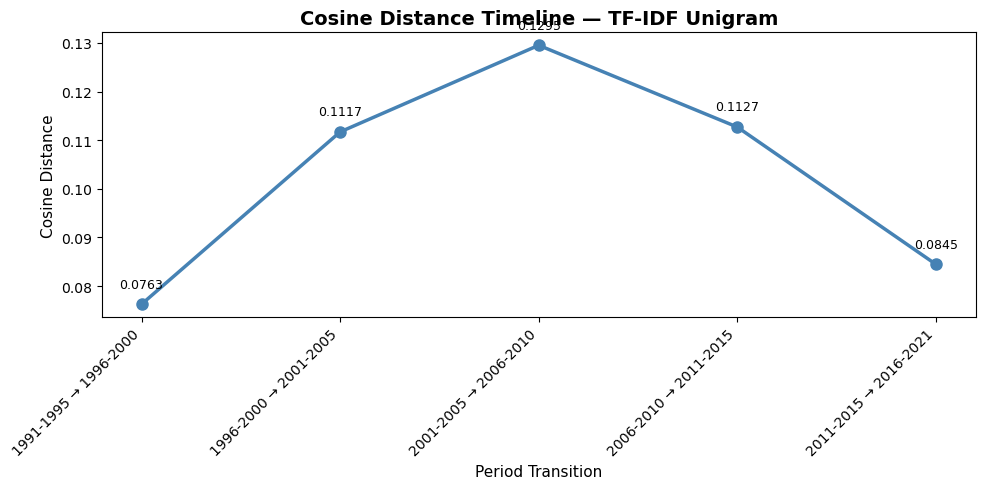

Saved: ../figures/cosine_distance_tfidf.png


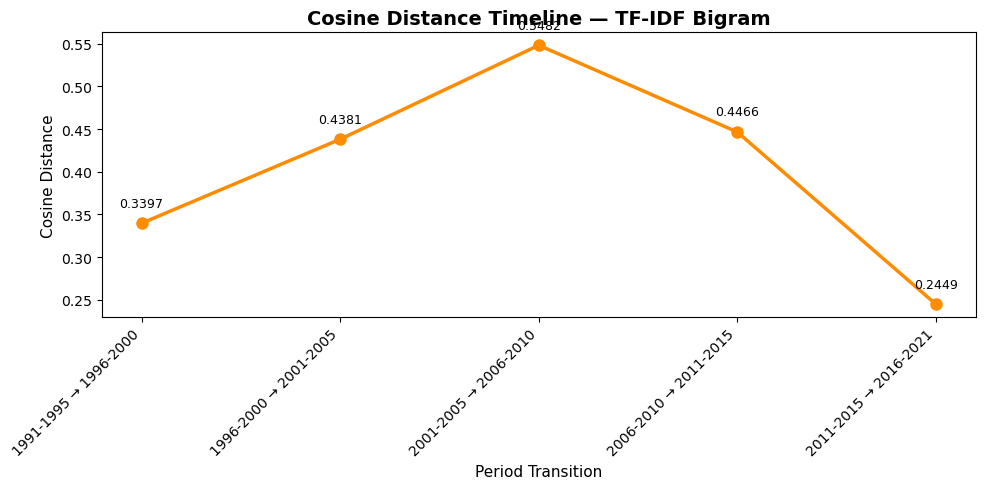

Saved: ../figures/cosine_distance_bigram.png


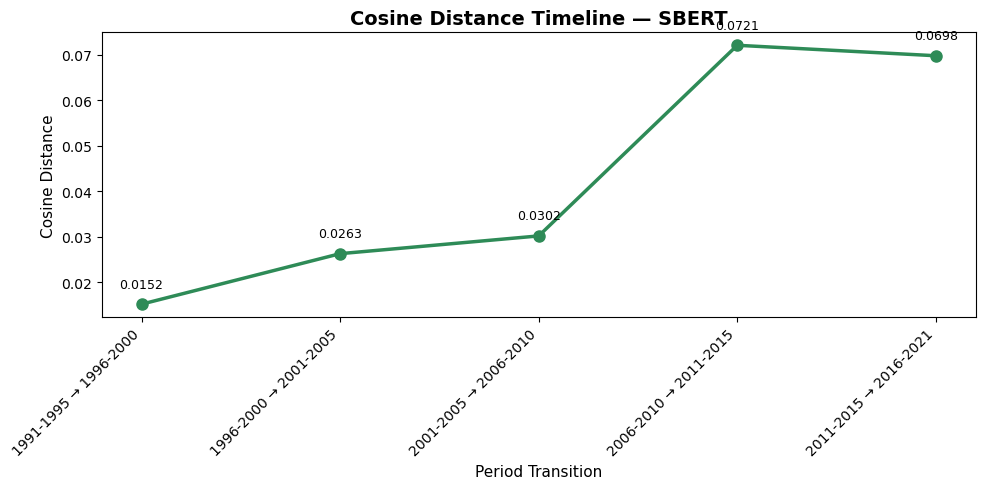

Saved: ../figures/cosine_distance_sbert.png


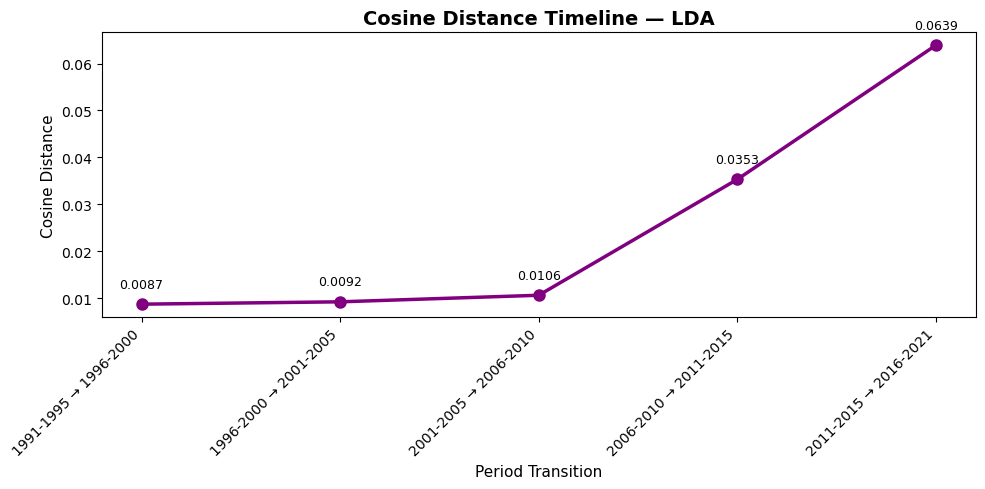

Saved: ../figures/cosine_distance_lda.png


In [43]:
def plot_distance_timeline(df_dist, title, color, save_path):
    plt.figure(figsize=(10, 5))
    plt.plot(
        df_dist["transition"],
        df_dist["distance"],
        marker="o",
        linewidth=2.5,
        color=color,
        markersize=8
    )
    for _, row in df_dist.iterrows():
        plt.annotate(
            f"{row['distance']:.4f}",
            (row["transition"], row["distance"]),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9
        )
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Period Transition", fontsize=11)
    plt.ylabel("Cosine Distance", fontsize=11)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")

plot_distance_timeline(
    tfidf_distances,
    "Cosine Distance Timeline — TF-IDF Unigram",
    color="steelblue",
    save_path="../figures/cosine_distance_tfidf.png"
)

plot_distance_timeline(
    bigram_distances,
    "Cosine Distance Timeline — TF-IDF Bigram",
    color="darkorange",
    save_path="../figures/cosine_distance_bigram.png"
)

plot_distance_timeline(
    sbert_distances,
    "Cosine Distance Timeline — SBERT",
    color="seagreen",
    save_path="../figures/cosine_distance_sbert.png"
)

plot_distance_timeline(
    lda_distances,
    "Cosine Distance Timeline — LDA",
    color="purple",
    save_path="../figures/cosine_distance_lda.png"
)

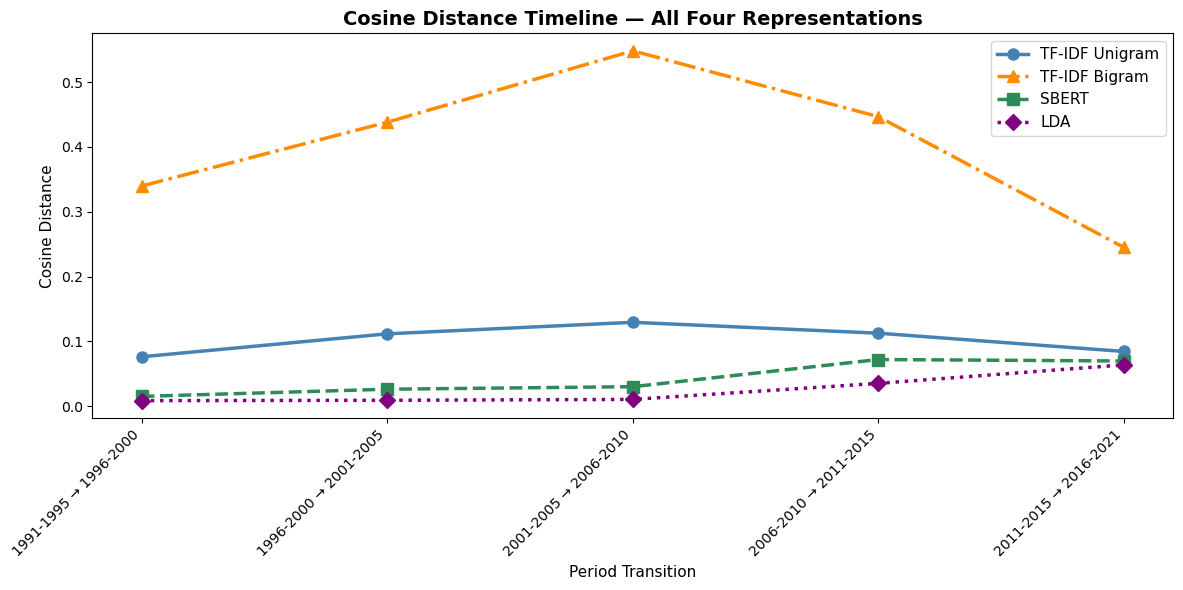

Saved: ../figures/cosine_distance_comparison.png


In [44]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    tfidf_distances["transition"],
    tfidf_distances["distance"],
    marker="o", linewidth=2.5,
    color="steelblue", label="TF-IDF Unigram",
    markersize=8
)

ax.plot(
    bigram_distances["transition"],
    bigram_distances["distance"],
    marker="^", linewidth=2.5,
    color="darkorange", label="TF-IDF Bigram",
    markersize=8, linestyle="-."
)

ax.plot(
    sbert_distances["transition"],
    sbert_distances["distance"],
    marker="s", linewidth=2.5,
    color="seagreen", label="SBERT",
    markersize=8, linestyle="--"
)

ax.plot(
    lda_distances["transition"],
    lda_distances["distance"],
    marker="D", linewidth=2.5,
    color="purple", label="LDA",
    markersize=8, linestyle=":"
)

ax.set_title(
    "Cosine Distance Timeline — All Four Representations",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Period Transition", fontsize=11)
ax.set_ylabel("Cosine Distance", fontsize=11)
ax.legend(fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/cosine_distance_comparison.png", dpi=150)
plt.show()
print("Saved: ../figures/cosine_distance_comparison.png")

In [45]:
tfidf_breakpoint  = tfidf_distances.loc[tfidf_distances["distance"].idxmax()]
bigram_breakpoint = bigram_distances.loc[bigram_distances["distance"].idxmax()]
sbert_breakpoint  = sbert_distances.loc[sbert_distances["distance"].idxmax()]
lda_breakpoint    = lda_distances.loc[lda_distances["distance"].idxmax()]

print("BREAKPOINT ANALYSIS")

print(f"\nTF-IDF Unigram biggest shift:")
print(f"  Transition : {tfidf_breakpoint['transition']}")
print(f"  Distance   : {tfidf_breakpoint['distance']}")

print(f"\nTF-IDF Bigram biggest shift:")
print(f"  Transition : {bigram_breakpoint['transition']}")
print(f"  Distance   : {bigram_breakpoint['distance']}")

print(f"\nSBERT biggest shift:")
print(f"  Transition : {sbert_breakpoint['transition']}")
print(f"  Distance   : {sbert_breakpoint['distance']}")

print(f"\nLDA biggest shift:")
print(f"  Transition : {lda_breakpoint['transition']}")
print(f"  Distance   : {lda_breakpoint['distance']}")

print("\nAGREEMENT ANALYSIS")

transitions = {
    tfidf_breakpoint["transition"],
    bigram_breakpoint["transition"],
    sbert_breakpoint["transition"],
    lda_breakpoint["transition"]
}

if len(transitions) == 1:
    print(f"All four methods AGREE")
    print(f"Biggest shift at: {tfidf_breakpoint['transition']}")
elif tfidf_breakpoint["transition"] == bigram_breakpoint["transition"]:
    print(f"TF-IDF Unigram and Bigram AGREE:")
    print(f"Biggest shift at: {tfidf_breakpoint['transition']}")
    if sbert_breakpoint["transition"] == lda_breakpoint["transition"]:
        print(f"SBERT and LDA AGREE:")
        print(f"Biggest shift at: {sbert_breakpoint['transition']}")
    else:
        print(f"SBERT says: {sbert_breakpoint['transition']}")
        print(f"LDA says  : {lda_breakpoint['transition']}")
else:
    print(f"All methods DISAGREE")
    print(f"TF-IDF Unigram : {tfidf_breakpoint['transition']}")
    print(f"TF-IDF Bigram  : {bigram_breakpoint['transition']}")
    print(f"SBERT          : {sbert_breakpoint['transition']}")
    print(f"LDA            : {lda_breakpoint['transition']}")

# Full rankings
print("\n--- TF-IDF Unigram ranked ---")
print(tfidf_distances[["transition","distance"]]
      .sort_values("distance", ascending=False)
      .to_string(index=False))

print("\n--- TF-IDF Bigram ranked ---")
print(bigram_distances[["transition","distance"]]
      .sort_values("distance", ascending=False)
      .to_string(index=False))

print("\n--- SBERT ranked ---")
print(sbert_distances[["transition","distance"]]
      .sort_values("distance", ascending=False)
      .to_string(index=False))

print("\n--- LDA ranked ---")
print(lda_distances[["transition","distance"]]
      .sort_values("distance", ascending=False)
      .to_string(index=False))

BREAKPOINT ANALYSIS

TF-IDF Unigram biggest shift:
  Transition : 2001-2005 → 2006-2010
  Distance   : 0.1295

TF-IDF Bigram biggest shift:
  Transition : 2001-2005 → 2006-2010
  Distance   : 0.5482

SBERT biggest shift:
  Transition : 2006-2010 → 2011-2015
  Distance   : 0.07209999859333038

LDA biggest shift:
  Transition : 2011-2015 → 2016-2021
  Distance   : 0.0639

AGREEMENT ANALYSIS
TF-IDF Unigram and Bigram AGREE:
Biggest shift at: 2001-2005 → 2006-2010
SBERT says: 2006-2010 → 2011-2015
LDA says  : 2011-2015 → 2016-2021

--- TF-IDF Unigram ranked ---
           transition  distance
2001-2005 → 2006-2010    0.1295
2006-2010 → 2011-2015    0.1127
1996-2000 → 2001-2005    0.1117
2011-2015 → 2016-2021    0.0845
1991-1995 → 1996-2000    0.0763

--- TF-IDF Bigram ranked ---
           transition  distance
2001-2005 → 2006-2010    0.5482
2006-2010 → 2011-2015    0.4466
1996-2000 → 2001-2005    0.4381
1991-1995 → 1996-2000    0.3397
2011-2015 → 2016-2021    0.2449

--- SBERT ranked ---


### Summary of Findings

#### Breakpoints Identified
| Method | Biggest Shift | Distance |
|---|---|---|
| TF-IDF Unigram | 2001-2005 → 2006-2010 | 0.1295 |
| TF-IDF Bigram  | 2001-2005 → 2006-2010 | 0.5482 |
| SBERT          | 2006-2010 → 2011-2015 | 0.0721 |
| LDA            | 2011-2015 → 2016-2021 | 0.0639 |

#### Do Methods Agree?
TF-IDF Unigram and Bigram AGREE — both identify 2001-2005 → 2006-2010 
as the biggest shift. SBERT DISAGREES — it identifies 2006-2010 → 
2011-2015 as the biggest semantic shift, one period later. LDA 
DISAGREES with all three — it identifies 2011-2015 → 2016-2021 as 
the biggest topic-level shift, one further period later again.

#### Key Insights

**1. A cascade effect across all four representations**
Each method detects the biggest shift one period later than the previous:
- TF-IDF (vocabulary) → 2001-2005 → 2006-2010 (vocabulary changed first)
- SBERT  (semantics)  → 2006-2010 → 2011-2015 (meaning changed next)
- LDA    (topics)     → 2011-2015 → 2016-2021 (research topics changed last)

This suggests the NLP paradigm shift was a gradual cascade — surface 
vocabulary changed first, followed by semantic meaning, followed by 
a full shift in research topics.

**2. Bigram distances are much larger than all other methods**
- Unigram distances range from 0.076 to 0.130
- Bigram distances range from 0.245 to 0.548
- SBERT distances range from 0.015 to 0.072
- LDA distances range from 0.009 to 0.064

Domain-specific phrases like "deep learning" and "language model" 
are far more era-specific than individual words, making bigrams 
the most sensitive detector of vocabulary change.

**3. LDA distances are the smallest overall**
LDA topic distributions change the most gradually of all four 
representations. This makes sense — broad research topics shift 
more slowly than individual words or semantic meaning. The field 
can adopt new vocabulary and new concepts while still broadly 
working on the same high-level themes.

**4. The transformer era pattern**
The 2011-2015 → 2016-2021 transition ranks differently across methods:
- Unigram: 0.0845 (4th largest — smallest shift)
- Bigram:  0.2449 (5th largest — smallest shift)
- SBERT:   0.0698 (2nd largest — continued shift)
- LDA:     0.0639 (1st largest — biggest topic shift)

TF-IDF methods show the transformer era as the least dramatic 
vocabulary shift, while LDA shows it as the most dramatic topic 
shift. This suggests the transformer era did not introduce entirely 
new vocabulary but fundamentally reorganised what researchers were 
working on.

**5. Alignment with known NLP history**
| Period | Known Event | Detected by |
|---|---|---|
| 2001-2005 → 2006-2010 | Rise of statistical ML in NLP | TF-IDF Unigram + Bigram |
| 2006-2010 → 2011-2015 | Deep learning enters NLP (~2012) | SBERT |
| 2011-2015 → 2016-2021 | Transformer era (BERT 2018) | LDA |